In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/dff_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/dfo_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000]_True.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


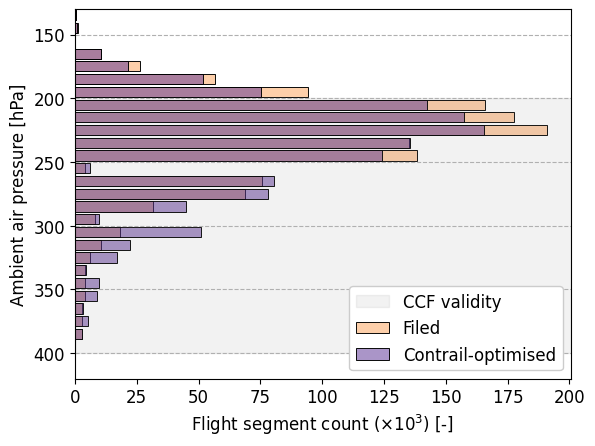

In [3]:
fig, ax = plt.subplots()
sns.histplot(y=dff.air_pressure / 100, bins=np.arange(100, 400, 10), shrink=0.8, alpha=0.5, label="Filed",
             color=sns.color_palette("Oranges")[2])
sns.histplot(y=dfo.air_pressure / 100, bins=np.arange(100, 400, 10), shrink=0.8, alpha=0.5, label="Contrail-optimised",
             color=sns.color_palette("Purples")[5])

plt.axhspan(400, 200, alpha=0.1, color="grey", label="CCF validity")

plt.grid(axis="y", linestyle="--")
ax.tick_params(labelsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x / 1e3:.0f}'))
ax.set_xlabel("Flight segment count ($\\times 10^3$) [-]", fontsize=12)
ax.set_ylim([420, 130])
ax.set_ylabel("Ambient air pressure [hPa]", fontsize=12)

plt.legend(loc="lower right", facecolor="w", framealpha=1, fontsize=12)

plt.savefig("./figures/figB1.png", dpi=300, bbox_inches="tight")